# Week 10 Problem Set


In [176]:
%load_ext nb_mypy
%nb_mypy Off

The nb_mypy extension is already loaded. To reload it, use:
  %reload_ext nb_mypy


In [177]:
from typing import TypeAlias
from typing import Optional, Any    

Number: TypeAlias = int | float

In [178]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.axes as axes
import seaborn as sns
from IPython.display import display

## Homeworks

**HW0.** Copy and paste some of the functions from you cohort sessions and previous exercises that you will need in this homework. See below template and the list here:
- `normalize_z()`
- `get_features_targets()`
- `calc_linreg()`
- `prepare_feature()`
- `predict_linreg()`
- `split_data()`
- `r2_score()`
- `mean_squared_error()`

Then do the following:
- Read the CSV file `housing_processed.csv` and extract the following columns:
    - x data: RM, DIS, and INDUS columns 
    - y data: MEDV column
- Normalize the features using z normalization. 
- Plot the data using scatter plot. Use the following columns:


In [179]:
def normalize_z(array: np.ndarray, columns_means: Optional[np.ndarray]=None, 
                columns_stds: Optional[np.ndarray]=None) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    assert columns_means is None or columns_means.shape == (1, array.shape[1])
    assert columns_stds is None or columns_stds.shape == (1, array.shape[1])
    
    if columns_means is None:
        columns_means = np.mean(array, axis=0,keepdims=True)
    if columns_stds is None:
        columns_stds = np.std(array, axis=0,keepdims=True)
    
    out = (array - columns_means) / columns_stds
    
    assert out.shape == array.shape
    assert columns_means.shape == (1, array.shape[1])
    assert columns_stds.shape == (1, array.shape[1])
    return out, columns_means, columns_stds



def get_features_targets(df: pd.DataFrame, 
                         feature_names: list[str], 
                         target_names: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    
    df_feature = df[feature_names]
    df_target = df[target_names]
    
    return df_feature, df_target

def prepare_feature(np_feature: np.ndarray) -> np.ndarray:
    # create a 1D array (a column) of only '1's
    one_matrix = np.ones( (np_feature.shape[0], 1) )
    
    # put this side by side (vertically) inside the X
    X = np.concatenate((one_matrix, np_feature), axis=1)
    
    assert X.shape == (np_feature.shape[0], np_feature.shape[1] + 1)
    return X

def predict_linreg(array_feature: np.ndarray, beta: np.ndarray) -> np.ndarray:
    beta: np.ndarray = beta.reshape((-1,1))
    assert array_feature.ndim == 2
    assert array_feature.shape[1] + 1 == beta.shape[0]
    
    # add column of 1s to help with matrix multiplication
    # like multiplication in the equation but for computer, we need to translate to matrix
    X = prepare_feature(array_feature)
    # predicted result using the euqation
    result = calc_linreg(X, beta)
    
    assert result.shape == (array_feature.shape[0], 1)
    return result

def calc_linreg(X: np.ndarray, beta: np.ndarray) -> np.ndarray:
    beta: np.ndarray = beta.reshape((-1,1))
    assert X.ndim == 2
    assert X.shape[1] == beta.shape[0]
    
    result = np.matmul(X, beta)
    
    assert result.shape == (X.shape[0], 1)
    return result

def split_data(array_features: np.ndarray, array_target: np.ndarray, 
               random_state: Optional[int]=None, 
               test_size: float=0.5) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    
    # initialize the random state
    np.random.seed(random_state)
    
    size_to_test = int(test_size * len(array_features))
    
    # get index of the rows we choose to test
    test_idx = np.random.choice(array_features.shape[0], size=size_to_test, replace=False)
    
    # convert to DataFrame and get the rows
    df_f = pd.DataFrame(array_features)
    df_t = pd.DataFrame(array_target)
    
    array_feature_test = df_f.loc[test_idx, :].to_numpy()
    array_target_test = df_t.loc[test_idx, :].to_numpy()
    
    array_feature_train = df_f.drop(test_idx).to_numpy()
    array_target_train = df_t.drop(test_idx).to_numpy()
    
    return array_feature_train, array_feature_test, array_target_train, array_target_test
    

 
  


def r2_score(y: np.ndarray, ypred: np.ndarray) -> float:
    # axis = 0, sum all rows together (vertically, in a column)
    
    # calculate sum of squares (residuals)
    ss_red = np.sum((y - ypred) * (y - ypred), axis=0)
    
    # calculate sum of squares (total)
    y_mean = np.mean(y)
    ss_tot = np.sum((y - y_mean) * (y - y_mean), axis=0)
    
    r_squared = 1 - (ss_red / ss_tot)
    
    return r_squared

def mean_squared_error(target: np.ndarray, pred: np.ndarray) -> float:
    mse = np.mean((target - pred) * (target - pred))
        
    return mse

In [ ]:
import os
FILE_LOC = os.getenv('UPLOADED_FILES')
# FILE_LOC = 'data'
if FILE_LOC is None:
    FILE_LOC = "."
# the file location is at FILE_LOC + "/housing_processed.csv"
# Read the CSV file
df: pd.DataFrame = pd.read_csv(FILE_LOC + '/housing_processed.csv')

# Extract the features and the targets
ft_out: tuple[pd.DataFrame, pd.DataFrame] = get_features_targets(df,['RM', 'DIS', 'INDUS'],['MEDV'])
df_features, df_target = ft_out

# Normalize using z normalization
norm_out: tuple[np.ndarray, np.ndarray, np.ndarray] = normalize_z(df_features.to_numpy())
array_features,_,_ = norm_out


df_features: pd.DataFrame = pd.DataFrame(array_features, columns=df_features.columns)
display(df_features.describe())
display(df_target.describe())
assert np.isclose(df_features['RM'].mean(), 0)
assert np.isclose(df_features['DIS'].mean(), 0)
assert np.isclose(df_features['INDUS'].mean(), 0)

assert np.isclose(df_features['RM'].std(), 1, rtol=1e-3)
assert np.isclose(df_features['DIS'].std(), 1, rtol=1e-3)
assert np.isclose(df_features['INDUS'].std(), 1, rtol=1e-3)

assert np.isclose(df_target['MEDV'].mean(), 22.532806)
assert np.isclose(df_target['MEDV'].std(), 9.197104)

assert np.isclose(df_features['RM'].median(), -0.10846, rtol=1e-3)
assert np.isclose(df_features['DIS'].median(), -0.279328, rtol=1e-3)
assert np.isclose(df_features['INDUS'].median(), -0.210985, rtol=1e-3)

,RM,DIS,INDUS
count,5.060000e+02,5.060000e+02,5.060000e+02
mean,-1.088282e-16,-8.425408e-17,2.106352e-16
std,1.000990e+00,1.000990e+00,1.000990e+00
min,-3.880249e+00,-1.267069e+00,-1.557842e+00
25%,-5.686303e-01,-8.056878e-01,-8.676906e-01
50%,-1.084655e-01,-2.793234e-01,-2.110985e-01
75%,4.827678e-01,6.623709e-01,1.015999e+00
max,3.555044e+00,3.960518e+00,2.422565e+00


,MEDV
count,506.000000
mean,22.532806
std,9.197104
min,5.000000
25%,17.025000
50%,21.200000
75%,25.000000
max,50.000000


In [181]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


In [182]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

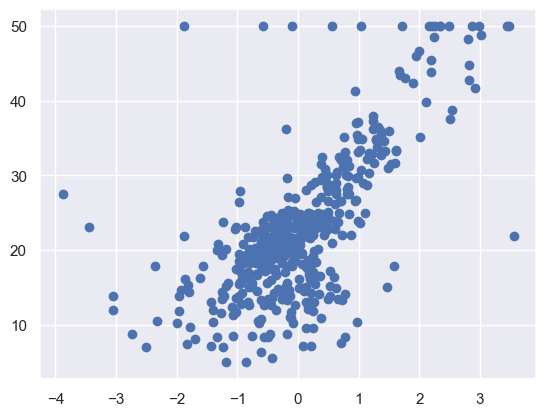

In [183]:
sns.set()
plt.scatter(df_features["RM"], df_target)

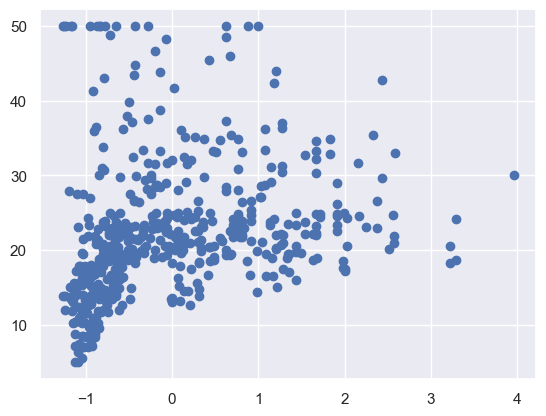

In [184]:
plt.scatter(df_features["DIS"], df_target)

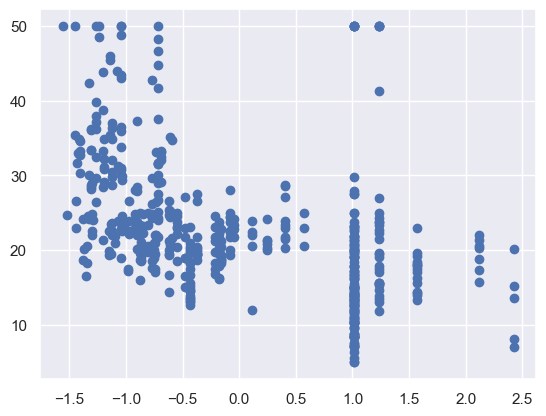

In [185]:
plt.scatter(df_features["INDUS"], df_target)

**HW1.** *Multiple variables cost function:* Write a function `compute_cost_linreg()` to compute the cost function of a linear regression model. The function should take in two 2-D numpy arrays. The first one is the matrix of the linear equation and the second one is the actual target value.

Recall that:

$$J(\hat{\beta}_0, \hat{\beta}_1) = \frac{1}{2m}\Sigma^m_{i=1}\left(\hat{y}(x^i)-y^i\right)^2$$

where

$$\hat{y}(x) =  \hat{\beta}_0 + \hat{\beta}_1 x_1 + \hat{\beta}_2 x_2 + \ldots + \hat{\beta}_n x_n$$

The function should receive three Numpy arrays:
- `X`: is the feature 2D Numpy array
- `y`: is the target 2D Numpy array
- `beta`: is the parameter 2D Numpy array

The function should return the cost which is a float.

You can use the following function in your code:
- `np.matmul(array1, array2)`

Note that if you wrote your Cohort session's `compute_cost_linreg()` using proper Matrix operations to do the square and the summation, the code will be exactly the same here and you just need to copy and paste it here.

In [186]:
def compute_cost_linreg(X: np.ndarray, y: np.ndarray, beta: np.ndarray) -> np.ndarray:
    beta: np.ndarray = beta.reshape((-1,1))
    y: np.ndarray = y.reshape((-1,1))
    assert X.ndim == 2
    assert X.shape[1] == beta.shape[0]
    assert y.shape == (X.shape[0], 1)
    
    # take the y_hat result
    y_hat = calc_linreg(X, beta)
    
    # everything in equation we expression in matrix multiplication
    
    # error
    error = y_hat - y
    
    # calculate the cost function
    m = X.shape[0] # total number of data points
    error_transpose = error.transpose()
    
    J = (1/(2*m)) * np.matmul(error_transpose, error)
    
    assert J.shape == (1, 1)
    return np.squeeze(J)


In [187]:
X: np.ndarray = prepare_feature(df_features.to_numpy())
target: np.ndarray = df_target.to_numpy()

assert isinstance(X, np.ndarray)
assert isinstance(target, np.ndarray)
assert X.shape == (506, 4)
assert target.shape == (506, 1)

In [188]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

In [189]:
beta: np.ndarray = np.zeros((4,1))
J: np.ndarray = compute_cost_linreg(X, target, beta)
print(J)
assert np.isclose(J, 296.0734, rtol=1e-3)

beta: np.ndarray = np.ones((4,1))
J: np.ndarray = compute_cost_linreg(X, target, beta)
print(J)
assert np.isclose(J, 270.4083, rtol=1e-3)

beta: np.ndarray = np.array([-1, 2, 1, 2]).reshape((4,1))
J: np.ndarray = compute_cost_linreg(X, target, beta)
print(J)
assert np.isclose(J, 314.8510, rtol=1e-3)


296.0734584980237
270.4053445844303
314.84864603213333


In [190]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

**HW2.** *Gradient Descent:* Write a function called `gradient_descent_linreg()` that takes in four parameters:
- `X`: is a 2-D numpy array for the features
- `y`: is a vector array for the target
- `alpha`: is the learning rate
- `num_iters`: is the number of iteration to perform

The function should return two arrays:
- `beta`: is coefficient at the end of the iteration
- `J_storage`: is the array that stores the cost value at each iteration

You can use some of the following functions:
- `np.matmul(array1, array2)`: which is to do matrix multiplication on two Numpy arrays.
- `compute_cost_linreg()`: which the function you created in the previous problem set to compute the cost.

Note that if you use proper matrix operations in your cohort sessions for the gradient descent function, the code will be the same here.

In [191]:
def gradient_descent_linreg(X: np.ndarray, 
                            y: np.ndarray, 
                            beta: np.ndarray, 
                            alpha: float, 
                            num_iters: int) -> tuple[np.ndarray, np.ndarray]:
    y: np.ndarray = y.reshape((-1,1))
    beta: np.ndarray = beta.reshape((-1,1))
    assert X.ndim == 2
    assert X.shape[1] == beta.shape[0]
    assert y.shape == (X.shape[0], 1)
    
    X_transpose = X.transpose()
    m = X.shape[0] #total num of data points
    
    # allocate some spaces for J_storage first
    J_storage = np.zeros((num_iters, 1))
    
    # total number of times to iter
    for i in range(num_iters):
        y_hat = calc_linreg(X, beta)
        error = y_hat - y
        
        # calculate next beta (formula in class notes)
        beta = beta - alpha * (1/m) * np.matmul(X_transpose, error)
        
        # calculate next J in each iteration
        # store in the correct slot inside the storage
        J_storage[i] = compute_cost_linreg(X, y, beta)
    
    
    
    assert beta.shape == (X.shape[1], 1)
    assert J_storage.shape == (num_iters, 1)
    return beta, J_storage


In [192]:
iterations: int = 1500
alpha: float = 0.01
beta: np.ndarray = np.zeros((4,1))

model_out: tuple[np.ndarray, np.ndarray] = gradient_descent_linreg(X, target, beta, alpha, iterations)
beta, J_storage = model_out
print(beta)
assert np.isclose(beta[0], 22.5328, rtol=1e-3)
assert np.isclose(beta[1], 5.4184, rtol=1e-3)
assert np.isclose(beta[2], -0.9029, rtol=1e-3)
assert np.isclose(beta[3], -2.9554, rtol=1e-3)

[[22.53279993]
 [ 5.41845013]
 [-0.90294093]
 [-2.95543739]]


In [193]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

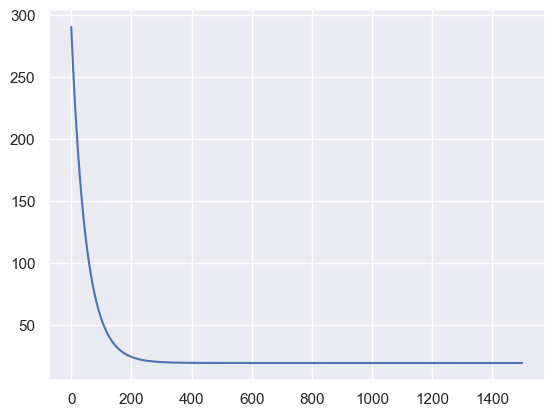

In [194]:
plt.plot(J_storage)

**HW3.** Do the following tasks:
- Get the features and the targets.
    - features: RM, DIS, INDUS
    - target: MEDV
- Use the previous functions called `predict()` to calculated the predicted values given the features and the model. 
- Create a target numpy array from the data frame.

In [195]:
# This is from the previous result
beta: np.ndarray = np.array([[22.53279993],
       [ 5.42386374],
       [-0.90367449],
       [-2.95818095]])

# Extract the feature and the target
ft_out: tuple[pd.DataFrame, pd.DataFrame] = get_features_targets(df,['RM', 'DIS', 'INDUS'],['MEDV'])
df_features, df_target = ft_out

# normalize and output the numpy array
norm_out: tuple[np.ndarray, np.ndarray, np.ndarray] = normalize_z(df_features.to_numpy())
array_feature, _, _ = norm_out

# Call predict()
pred: np.ndarray = predict_linreg(array_feature, beta)

# Change target to numpy array
target: np.ndarray = df_target.to_numpy()

In [196]:
assert isinstance(pred, np.ndarray)
assert np.isclose(pred.mean(), 22.5328, rtol=1e-3)
assert np.isclose(pred.std(), 6.7577, rtol=1e-3)

In [197]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

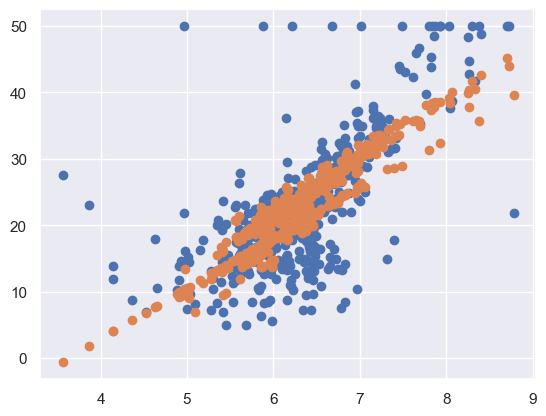

In [198]:
plt.scatter(df_features["RM"],target)
plt.scatter(df_features["RM"],pred)

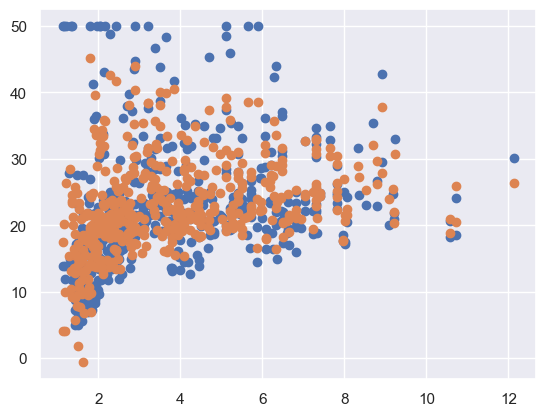

In [199]:
plt.scatter(df_features["DIS"],target)
plt.scatter(df_features["DIS"],pred)

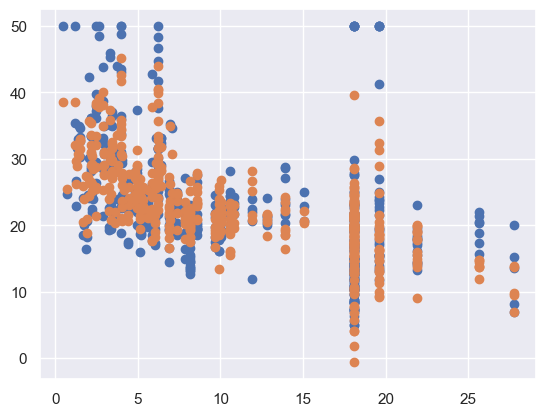

In [200]:
plt.scatter(df_features["INDUS"],target)
plt.scatter(df_features["INDUS"],pred)

**HW4.** *Splitting data:*  Do the following tasks:
- Extract the following:
    - features: RM, DIS, and INDUS
    - target: MEDV 
- Use Week 9's function `split_data()` to split the data into train and test using `random_state=100` and `test_size=0.3`.
- Use the `build_model()` function from your cohort problem set to build the model and call `gradient_descent_linreg()` to obtain the `beta`.
- Use the test data set to get the predicted values.

You need to replace the `None` in the code below with other a function call or any other Python expressions. 

In [201]:
# copy from your cohort problem set

def build_model_linreg(array_feature_train: np.ndarray,
                       array_target_train: np.ndarray,
                       beta: Optional[np.ndarray] = None,
                       alpha: float = 0.01,
                       iterations: int = 1500) -> tuple[dict[str, Any], np.ndarray]:
    if beta is None:
        beta = np.zeros((array_feature_train.shape[1] + 1, 1)) 
    assert beta.shape == (array_feature_train.shape[1] + 1, 1)
    model: dict[str, Any] = {}
    
    # DOING EVERYTHIING IN CS4
    array_feature_train_z,  means, stds = normalize_z(array_feature_train)
    
    X = prepare_feature(array_feature_train_z)
    target = array_target_train
    
    model_out = gradient_descent_linreg(X, target, beta, alpha, iterations)
    beta, J_storage = model_out
    
    model = {'beta': beta, 'means': means, 'stds': stds}
    
    assert model["beta"].shape == (array_feature_train.shape[1] + 1, 1)
    assert model["means"].shape == (1, array_feature_train.shape[1])
    assert model["stds"].shape == (1, array_feature_train.shape[1])
    assert J_storage.shape == (iterations, 1)
    return model, J_storage

In [202]:
# Extract the features and the target
ft_out: tuple[pd.DataFrame, pd.DataFrame] = get_features_targets(df, ["RM", 'DIS', 'INDUS'], ["MEDV"])
df_features, df_target = ft_out

# Split the data set into training and test
split_out: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray] = split_data(df_features.to_numpy(), df_target.to_numpy(), random_state=100, test_size=0.3)
df_features_train, df_features_test, df_target_train, df_target_test = split_out

# call build_model_linreg() function
model_out: tuple[np.ndarray, np.ndarray] = build_model_linreg(df_features_train, df_target_train)
model, J_storage = model_out

# normalize the test features 
# normalize the test data with the mean, std of the training model (so become same scale)
norm_out: tuple[np.ndarray, np.ndarray, np.ndarray] = normalize_z(df_features_test, model["means"], model["stds"])
array_feature_test, _, _ = norm_out

# call the predict_linreg() method
beta = model["beta"] #get the beta from the model(equation) we found
pred: np.ndarray = predict_linreg(array_feature_test, beta)

In [203]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

In [204]:
assert isinstance(pred, np.ndarray)
assert pred.shape == (151, 1)
print(pred.mean(), pred.std())
assert np.isclose(pred.mean(), 22.0681, rtol=1e-3)
assert np.isclose(pred.std(), 6.2982, rtol=1e-3)

22.068185009617384 6.298212510043978


In [205]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

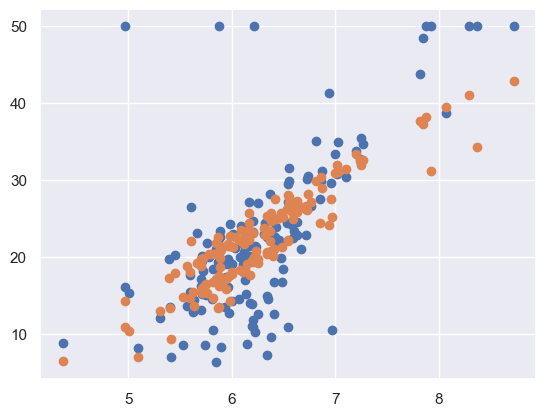

In [206]:
# These df are not df but in the test cases above
# the variables above all all numpy array but are named as df_features
# I DON"T kNOW WHY, just now these are all numpy arrays
plt.scatter(df_features_test[:, 0], df_target_test[:, 0])
plt.scatter(df_features_test[:, 0], pred)

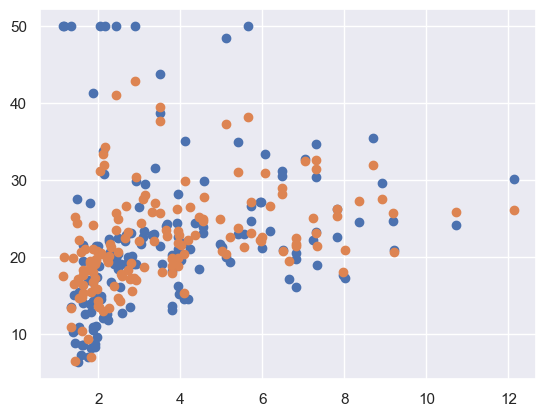

In [207]:
# These df are not df but in the test cases above
# the variables above all all numpy array but are named as df_features
# I DON"T kNOW WHY, just now these are all numpy arrays
plt.scatter(df_features_test[:, 1], df_target_test[:, 0])
plt.scatter(df_features_test[:, 1], pred)

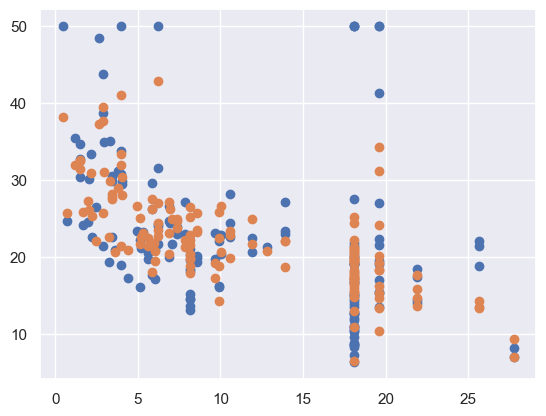

In [208]:
plt.scatter(df_features_test[:, 2], df_target_test[:, 0])
plt.scatter(df_features_test[:, 2], pred)

**HW5.** Calculate the coefficient of determination, $r^2$.

In [209]:
# change target test set to a numpy array

# AS BEFORE, THE TEST CASE IS WRONG
# THE DF_TARGET_TEST IS ACTUALLY NUMPY ARRAY, NOT DF
target: np.ndarray = df_target_test

# Calculate r2 scokowkodkoakdoakdoalling a function
r2: float = r2_score(target, pred)

print(r2)


[0.4718119]


In [210]:
assert np.isclose(r2, 0.47181, rtol=1e-3)

In [211]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

**HW6.** Calculate the mean squared error.

In [212]:
# Calculate the mse
mse: float = mean_squared_error(target, pred)

print(mse)


51.88586828427072


In [213]:
assert np.isclose(mse, 51.8858, rtol=1e-3)

In [214]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

**HW7.** *Polynomial Transformation:* Redo the steps for breast cancer data but this time we will use quadratic model. Use the following columns:
- x data: radius_mean
- y data: area_mean

We will create a quadratic hypothesis for this x and y data. To do that write a function `transform_features(df, colname, colname_transformed)` that takes in a dataframe for the features, the original column name, and the transformed column name. The function should add another column with the name `colname_transformed` with the value of column in `colname` transformed to its quadratic value. 

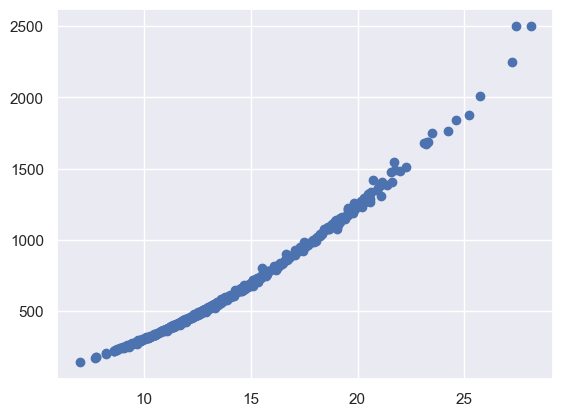

In [ ]:
import os
FILE_LOC = os.getenv('UPLOADED_FILES')
# FILE_LOC = 'data'
if FILE_LOC is None:
    FILE_LOC = "."

# Read from breast_cancer_data.csv file
df: pd.DataFrame = pd.read_csv(FILE_LOC + '/breast_cancer_data.csv')

# Extract feature and target
ft_out: tuple[pd.DataFrame, pd.DataFrame] = get_features_targets(df,['radius_mean'],['area_mean'])
df_feature, df_target = ft_out

plt.scatter(df_feature, df_target)

In [216]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


In [217]:
# write your function to create a quadratic feature of x

def transform_features(df_feature: pd.DataFrame, 
                       colname: str, 
                       colname_transformed: str) -> pd.DataFrame:
    
    df_feature[colname_transformed] = df_feature[colname].apply(lambda data: data * data)
    
    return df_feature


In [218]:
df_features: pd.DataFrame = transform_features(df_feature, "radius_mean", "radius_mean^2")

assert np.allclose(df_features.loc[:,"radius_mean^2"], df_features.loc[:,"radius_mean"] ** 2)

/var/folders/fz/m_dhqj9j15b8d_53j9wdsns80000gn/T/ipykernel_16753/926757396.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_feature[colname_transformed] = df_feature[colname].apply(lambda data: data * data)


In [219]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

In [220]:
# split data using random_state = 100 and 30% test size
split_out: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray] = split_data(df_features.to_numpy(), df_target.to_numpy(), random_state=100, test_size=0.3)
array_features_train, array_features_test, array_target_train, array_target_test = split_out

# normalize features
norm_out: tuple[np.ndarray, np.ndarray, np.ndarray] = normalize_z(array_features_train)
array_features_train_z, means, stds = norm_out

# change to numpy array and append column for feature
X: np.ndarray = prepare_feature(array_features_train_z)
target: np.ndarray = array_target_train

iterations: int = 1500
alpha: float = 0.01
beta: np.ndarray = np.zeros((3,1))

# call gradient_descent() function
model_out: tuple[dict, np.ndarray] = gradient_descent_linreg(X, target, beta, alpha, iterations)
beta, J_storage = model_out

In [221]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


In [222]:
print(beta)
assert np.isclose(beta[0], 646.0787, rtol=1e-3)
assert np.isclose(beta[1], 146.2331, rtol=1e-3)
assert np.isclose(beta[2], 201.7903, rtol=1e-3)

[[646.0787641 ]
 [146.23315177]
 [201.79029886]]


In [223]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

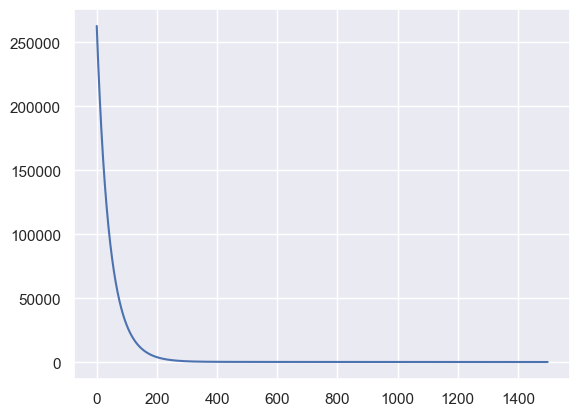

In [224]:
plt.plot(J_storage)

In [225]:
# change target to numpy array
beta: np.ndarray = np.array([[646.0787], [146.2331], [201.7903]])

# Replace the None below
target: np.ndarray = array_target_test

# normalize test features WITH THE TRAINING means/stds (same scale as the model was trained on)
norm_out: tuple[np.ndarray, np.ndarray, np.ndarray] = normalize_z(array_features_test, means, stds)
array_features_test_z, _, _ = norm_out

# call predict_linreg() function
pred: np.ndarray = predict_linreg(array_features_test_z, beta)

In [226]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###


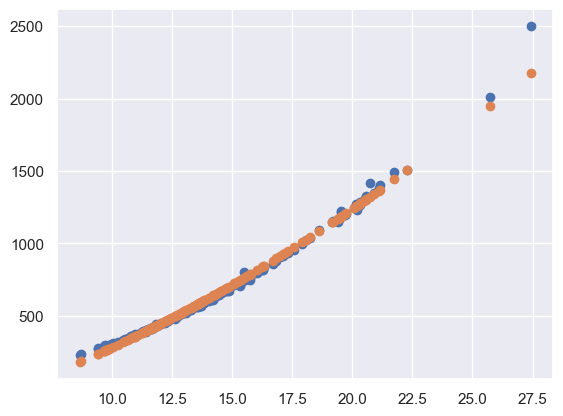

In [227]:
plt.scatter(array_features_test[:, 0], target)
plt.scatter(array_features_test[:, 0], pred)

In [228]:
target: np.ndarray = array_target_test
r2: float = r2_score(target, pred)
print(r2)
assert np.isclose(r2, 0.99235, rtol=1e-3)

[0.9923535]


In [229]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

In [230]:
target: np.ndarray = array_target_test
mse: float = mean_squared_error(target, pred)
print(mse)
assert np.isclose(mse, 984.54038, rtol=1e-3)

984.5403817190364


In [231]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

**HW8.** *Optional:* Redo the above tasks using Sci-kit learn libraries. You will need to use the following:
- [LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
- [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [r2_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html)
- [mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)
- [PolynomialFeatures](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)

In [232]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score as r2_score_sk
from sklearn.metrics import mean_squared_error as mse_sk
from sklearn.preprocessing import PolynomialFeatures

**Redo HW 4 using Scikit Learn**

In [233]:
import os
FILE_LOC = os.getenv('UPLOADED_FILES')
if FILE_LOC is None:
    FILE_LOC = "."
# Read the housing_processed.csv file
# df: pd.DataFrame = None

# extract the features from ["RM", "DIS", "INDUS"] and target from []"MEDV"]
# ft_out: tuple[pd.DataFrame, pd.DataFrame] = None
# df_features, df_target = ft_out

###
### YOUR CODE HERE
###

In [234]:
# Split the data into training and test data set using scikit-learn function
# split_out: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray] = None
# array_features_train, array_features_test, array_target_train, array_target_test = split_out

# normalize
# norm_out: tuple[np.ndarray, np.ndarray, np.ndarray] = None
# array_features_train_norm, _, _ = norm_out

# Instantiate LinearRegression() object
# model: LinearRegression = None

# Call the fit() method
# pass

###
### YOUR CODE HERE
###
# print(model.coef_, model.intercept_)
# assert np.isclose(model.coef_, [[5.12551999, -0.98161862, -3.22600156]]).all()
# assert np.isclose(model.intercept_, [22.60225989])

In [235]:
# Call the predict() method
# normalize array_features_test
# norm_out: tuple[np.ndarray, np.ndarray, np.ndarray] = None
# array_features_test_norm,_,_ = norm_out

# use the model to predict
# pred: np.ndarray = None

###
### YOUR CODE HERE
###

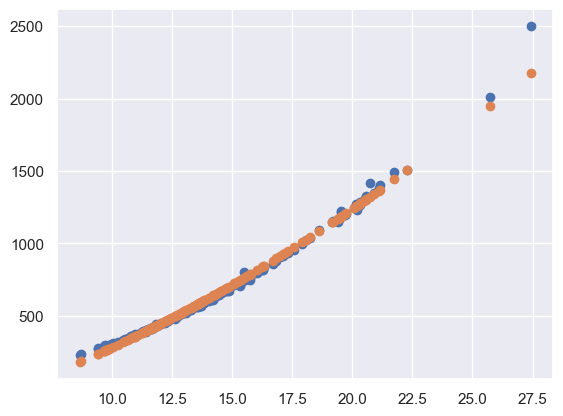

In [236]:
plt.scatter(array_features_test[:, 0], array_target_test)
plt.scatter(array_features_test[:, 0], pred)

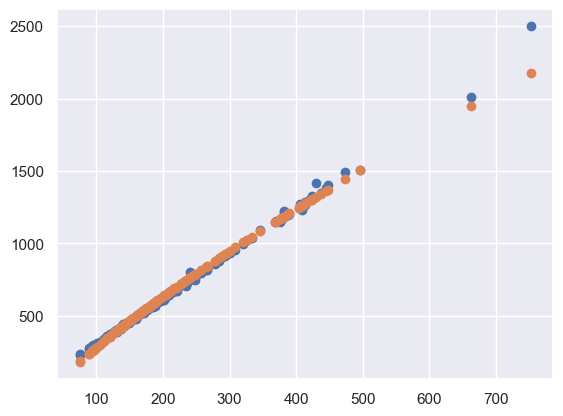

In [237]:
plt.scatter(array_features_test[:, 1], array_target_test)
plt.scatter(array_features_test[:, 1], pred)

In [238]:
# plt.scatter(array_features_test[:, 2], array_target_test)
# plt.scatter(array_features_test[:, 2], pred)

In [239]:
# r2: float = r2_score_sk(array_target_test, pred)
# print(r2)
# assert np.isclose(r2, 0.49017)

In [240]:
# mse: float = mse_sk(array_target_test, pred)
# print(mse)
# assert np.isclose(mse, 51.63812)

**Redo HW7 Using Scikit Learn**

In [241]:
# Read the file breast_cancer_data.csv
# df: pd.DataFrame = None
# extract feature from "radius_mean" and target from "area_mean"
# ft_out: tuple[pd.DataFrame, pd.DataFrame] = None
# df_feature, df_target = ft_out

###
### YOUR CODE HERE
###

In [242]:
# instantiate a PolynomialFeatures object with degree = 2
# poly: PolynomialFeatures = None

# call its fit_transform() method
# array_features: np.ndarray = None

# call train_test_split() to split the data
# split_out: tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray] = None
# array_features_train, array_features_test, array_target_train, array_target_test = split_out

# instantiate LinearRegression() object
# model: LinearRegression = None

# call its fit() method
# pass


    ###
    ### YOUR CODE HERE
    ###
# print(model.coef_, model.intercept_)
# assert np.isclose(model.coef_, [0., 3.69735512, 2.9925278 ]).all()
# assert np.isclose(model.intercept_, -32.3684598)

In [243]:
# Call the predict() method
# pred: np.ndarray = None

###
### YOUR CODE HERE
###

# print(type(pred), pred.mean(), pred.std())
# assert isinstance(pred, np.ndarray)
# assert np.isclose(pred.mean(), 672.508465)
# assert np.isclose(pred.std(), 351.50271)

In [244]:
# plt.scatter(array_features_test[:,1], array_target_test)
# plt.scatter(array_features_test[:,1], pred)

In [245]:
# r2: float = r2_score_sk(array_target_test, pred)
# print(r2)
# assert np.isclose(r2, 0.99729)

In [246]:
# mse: float = mse_sk(array_target_test, pred)
# print(mse)
# assert np.isclose(mse, 346.79479)